# Measurement of the signal strength

The likelihood $\mathcal{L}$ of a dataset $\mathcal{D}$ given a set of theory parameters $\mu$ is the product of the event probabilities. 

$$
    \mathcal{L} (\mathcal{D};\mu) = \prod_{i=1}^{n_{\rm obs}} p (x_i, z_i ; \mu)
$$

The likelihood can be extended, $\mathcal{L}_{ext}$, by multiply by a Poisson factor of the number of observed evetns $n_{obs}$ given the number of expected events $n_{exp}$. 

$$
    \mathcal{L}_{\rm ext} (\mathcal{D};\mu) = \frac{n_{\rm exp}(\mu)^{n_{\rm obs}} \, e^{-n_{\rm exp}(\mu)}}{n_{\rm obs}!}\prod_{i}^{n_{\rm obs}} p (x_i, z_i ; \mu).
$$

In [1]:
import json
import os
import pandas as pd
import numpy as np

import torch
from torch.utils.data import TensorDataset, DataLoader
torch.set_default_dtype(torch.float32)
torch.set_float32_matmul_precision('medium')
import lightning as L

from physics.simulation import mcfm
from physics.analysis import zz4l, zz2l2v
from physics.hstar import sigstr
from nsbi import carl

import matplotlib, matplotlib.pyplot as plt

# 0. Define the parameter space

The first thing to do is to define the parameter space that will define the set of hypotheses we wish to test.
For us, this is the signal strength parameter, which we will test between 0 and 4:

$$ 0 \leq \mu \leq 4 $$

In [2]:
mu_space = torch.linspace(0.0, 4.0, 401)

# 1. Open the "mystery" dataset

A dataset has been generated according to an unknown (to you) value of $\mu$ at the LHC luminosity of $300\,\mathrm{fb}^{-1}$. Let's open this dataset and read out for each event its (1) observables, and (2) number of occurrences.

In [3]:
lumi = 300.0  # ifb

data_dir = '/global/cfs/cdirs/m5295/NSBIData/h4l_data/'
events_obs = pd.read_csv(os.path.join(data_dir,'obs/mu_x.csv'))

features = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy', 
            'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy', 
            'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy', 
            'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']

events_obs_features = events_obs[features]
events_obs_n        = events_obs['n']

Note: Keep in mind that this is still a _simulated_ dataset, which means we must still take into account its weights. Of course, in a real LHC dataset, each entry represents exactly one entry.

** Question for participants **
1. Why would you want to create datasets of know $\mu$ values to scan? Why not just use the data to find what value of $\mu$ is maximizes the extended likleihood? 

## 2. Evaluating the likelihood: rate term

First, let us investigate the Poisson from the extended likelihood 

$$
    \mathcal{L}_{\rm rate}(\mathcal{D};\mu) = \mathcal{P}(n_{\rm obs};n_{\rm exp}) = \frac{n_{\rm exp}(\mu)^{n_{\rm obs}} \, e^{-n_{\rm exp}(\mu)}}{n_{\rm obs}!}
$$

Remeber, the number of expected events is explicitly dependent on the theory paramter $\mu$. 

### 2.(b) Compute the total expected number of events, $n_{exp}(\mu = 1)$

The expected number of events can be written as the inclusive cross section $\sigma(\mu)$ multiplied by the integrated luminosity $L$.

$$
n_{\rm exp}(\mu) = \sigma(\mu) \, L
$$

Note that the cross-section depends on the theory paramter $\mu$. These correspond to "visual" cross sections, i.e. after detector acceptance/efficiency effects, of the total $gg\to(h^{\ast}\to)ZZ\to 4\ell$ process. The independent signal/background/interference contributions to the signal+background+interference hypothesis is available.

In [4]:
with open(data_dir+'/sm/ggzz4l_xs.json', 'r') as f:
    xs = json.load(f)  # fb
    xs_sig_sm = np.prod(xs['sig'])
    xs_bkg_sm = np.prod(xs['bkg'])
    xs_int_sm = np.prod(xs['int'])
    xs_sbi_sm = np.prod(xs['sbi'])

n_sig_sm = xs_sig_sm * lumi
n_bkg_sm = xs_bkg_sm * lumi
n_int_sm = xs_int_sm * lumi
n_sbi_sm = xs_sbi_sm * lumi

### 2.(c) Compute the total expected number of events as a function of $\mu$

Recall that the number of expected events in our model depneds on our theory parameter as

$$
    n_{\rm exp}^{\mathrm{SBI}}(\mu) = \mu \, n_{\rm exp}^{\mathrm{S}} + \sqrt{\mu} \, n_{\rm exp}^{\mathrm{I}} + n_{\rm exp}^{\mathrm{B}}
$$


where the SM-expected number of events corresponds to $\mu = 1$.

In [5]:
n_sig_mu = n_sig_sm * mu_space
n_int_mu = n_int_sm * torch.sqrt(mu_space)
n_bkg_sm = n_bkg_sm  # I don't change!
n_sbi_mu = n_sig_mu + n_int_mu + n_bkg_sm

### 2.(d) Define & compute the Poisson likelihood

Using the quantities computed above, we can now compute the negative log of the likelihood (NLL) of the rate term as a function of $\mu$ as

$$
    - \log \left[ \mathcal{L}_{\rm rate}(\mathcal{D};\mu) \right]= {n_{\rm exp}(\mu)} - {n_{\rm obs}}\log\left[n_{\rm exp}(\mu)\right]  + \cancel{\log\left[n_{\rm obs}!\right]}
$$

**Question for participants**
1. Why can the $\log\left[n_{obs}!\right]$ term be ignored?

In [6]:
def neg_log_pois(n_obs, n_exp):
    """
    Evaluates the negative log-likelihood for a Poisson process.
    """
    return n_exp - n_obs * torch.log(n_exp)

t_rate = neg_log_pois(events_obs_n.sum(), n_sbi_mu)

Now let's plot our rate-only analysis result. As mentioned previous about the arbitrary minimum value of the NLL, we set it to be the zero-point of the test statistic.

$$
    t_{\rm rate} \equiv - 2 \left\{\log[\mathcal L_{\rm rate}(\mathcal D;\mu)] - \log [\mathcal L_{\rm rate}^{\min}(\mathcal D;\mu)]\right\} 
$$

**Question for participants**
1. What is the purose of subtracting by $\log [\mathcal L_{\rm rate}^{\min}(\mathcal D;\mu)]$? Is this strictly necessary? 

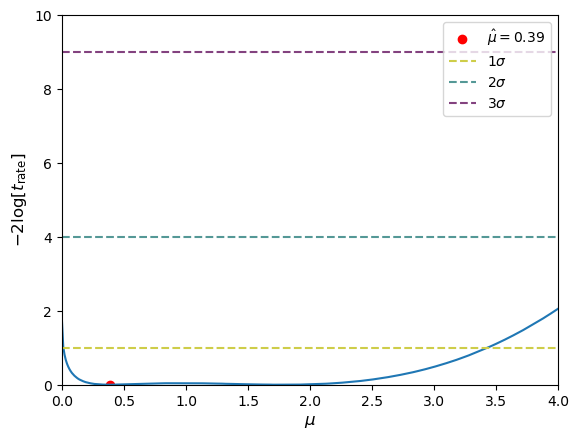

In [7]:
def plot_nll(mu_space, t):

    fig, ax = plt.subplots()
    
    t_min = torch.min(t)
    t -= t_min

    mu_fit = mu_space[torch.argmin(t)]

    ax.plot(mu_space.cpu(), t.cpu())
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 10)
    ax.scatter(mu_fit.cpu(), 0.0, color='red', label=f'$\\hat{{\\mu}} = {mu_fit:.2f}$')

    ax.hlines(1.0, 0, 4,color='#CECD49', linestyle='--', label=r'$1\sigma$')
    ax.hlines(4.0, 0, 4,color='#549896', linestyle='--', label=r'$2\sigma$')
    ax.hlines(9.0, 0, 4,color='#83427F', linestyle='--', label=r'$3\sigma$')

    ax.set_xlabel(r'$\mu$', fontsize=12)
    ax.set_ylabel(r'$-2 \log [t_{\rm rate}$]', fontsize=12)

    ax.legend()
    
    fig.show()

plot_nll(mu_space, t_rate)

Do you notice anything strange about the NLL curve? Perhaps more than one possible minimum?

## 3. Evaluating the likelihood (ratio): shape term

Here comes NSBI, which will estimate the shape term of our likelihood, and (hopefully) improve our results!

### 3.(a) Load the NN models

Let's first load the CARL models that we've trained in the previous tutorial.

In [8]:
run_dir = '/global/cfs/cdirs/m5295/NSBIData/carl_models/'
scaler_sbi_over_bkg, model_sbi_over_bkg = carl.utils.load_results(run_dir, 'sbi_over_bkg')
scaler_sig_over_bkg, model_sig_over_bkg = carl.utils.load_results(run_dir, 'sig_over_bkg')

/global/u1/e/emcgrady/miniforge3/envs/ml4fp/lib/python3.14/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


### 3.(b) Run the models over the dataset, and perform the likelihood ratio trick

This part should also be straightforward, given the previous exercise:

2. Scale the features of the observed data using the scaler from training.
3. Run the model over the scaled features.
4. Perform the likelihood trick over the output.

In [9]:
X_sig_over_bkg_sm = scaler_sig_over_bkg.transform(events_obs_features.to_numpy())
X_sbi_over_bkg_sm = scaler_sbi_over_bkg.transform(events_obs_features.to_numpy())

dl_sig_over_bkg_sm = DataLoader(TensorDataset(torch.tensor(X_sig_over_bkg_sm, dtype=torch.float32)), batch_size=1024) 
dl_sbi_over_bkg_sm = DataLoader(TensorDataset(torch.tensor(X_sbi_over_bkg_sm, dtype=torch.float32)), batch_size=1024) 

trainer = L.Trainer(accelerator='gpu', devices=1)
s_sig_over_bkg_sm = torch.cat(trainer.predict(model_sig_over_bkg, dl_sig_over_bkg_sm))
s_sbi_over_bkg_sm = torch.cat(trainer.predict(model_sbi_over_bkg, dl_sbi_over_bkg_sm))

C_sig_over_bkg = 1.0033742
C_sbi_over_bkg = 0.999466
# ---

r_sig_over_bkg_sm = s_sig_over_bkg_sm / (1 - s_sig_over_bkg_sm) * C_sig_over_bkg
r_sbi_over_bkg_sm = s_sbi_over_bkg_sm / (1 - s_sbi_over_bkg_sm) * C_sbi_over_bkg

/global/u1/e/emcgrady/miniforge3/envs/ml4fp/lib/python3.14/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /global/u1/e/emcgrady/miniforge3/envs/ml4fp/lib/pyth ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/global/u1/e/emcgrady/miniforge3/envs/ml4fp/lib/python3.14/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 

Predicting DataLoader 0: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 563/563 [00:02<00:00, 188.14it/s]


The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: EarlyStopping, ModelCheckpoint
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting DataLoader 0: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 563/563 [00:02<00:00, 210.21it/s]


### 3.(c) Evaluate the probability density ratio

Armed with the NSBI estiamte of each term in the probability mixture model, we can now evaluate the full SBI probability (ratio) as:

$$
\frac{\hat p_{\rm SBI} (x ; \mu)}{\hat p_{\rm B} (x)} = \frac{ (\mu - \sqrt{\mu})\, \sigma_{\rm S}\, \hat r_{\rm S} (x;\mu) + \sqrt{\mu} \, \sigma_{\rm SBI} \, \hat r_{\rm SBI} (x;\mu) + (1-\sqrt{\mu}) \, \sigma_{\rm B} }{ \mu \, \sigma_{\rm S} + \sqrt{\mu} \, \sigma_{\rm I} + \sigma_{\rm B} }
$$

Tip: if you want to compute all elements of the $N \times M$ tensor where $N$ is the number of entries in the dataset and $M$ is the number of $\mu$ values being tested, then you can utilize tensor broadcasting, here's an example:
```py
a.shape  # (N,)
b.shape  # (M,)
c = a[:,None] * b[None,:]
c.shape  # (N, M)
```

In [10]:
multiplier_sig = mu_space - torch.sqrt(mu_space)
multiplier_sbi = torch.sqrt(mu_space)
multiplier_bkg = 1 - torch.sqrt(mu_space)

r_sbi_over_bkg_mu = ( xs_sig_sm * multiplier_sig[None,:] * r_sig_over_bkg_sm[:,None] 
                     + xs_sbi_sm * multiplier_sbi[None,:] * r_sbi_over_bkg_sm[:,None] 
                     + xs_bkg_sm * multiplier_bkg[None,:] ) / (xs_sig_sm * mu_space + xs_int_sm * torch.sqrt(mu_space) + xs_bkg_sm)

Now let us consider the shape parameter of our extended likelihood. This shape parameter can be cast using the learned DRE as

$$
\mathcal{L}_{\rm shape}(\mathcal D;\mu) = \prod_{i}^{n_{\rm obs}} \hat{r}(x_i; \mu) = \prod_{i}^{n_{\rm obs}} \frac{\hat{p}_{\rm SBI}(x_i; \mu)}{\hat{p}_{\rm B}(x_i)}
$$

In this case, we define our test statistic as 

$$
    t_{\rm shape} \equiv - 2\sum_{i=1}^{n_{\rm obs}}\log[\mathcal L_{\rm shape}(\mathcal D;\mu)]
$$

This can be cast using our DRE as 

$$
\begin{aligned}
    \hat t_{\rm shape} 
    &= 
    - 2\sum_{i=1}^{n_{\rm obs}}w_i(x,z;\mu)\,\log\left[\hat r_{\rm SBI} (x_i ; \mu)\right] \\
    &= 
    - 2\sum_{i=1}^{n_{\rm obs}}w_i(x,z;\mu)\log\left[\frac{\hat p_{\rm SBI} (x_i ; \mu)}{\hat p_{\rm B} (x_i)}\right]
\end{aligned}
$$

**Questions for participants**
1. Why is $w_i(x,z;\mu)$ neceasry for this calculation?
1. Why can we use $\hat r(x ; \mu)$ in the above when the likelihood was defined using $p(x,z;\mu)$?

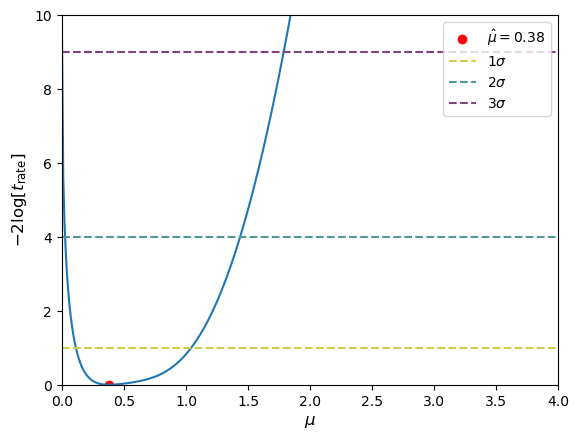

In [11]:
t_shape = -2 * torch.sum(torch.tensor(events_obs_n)[:,None] * torch.log(r_sbi_over_bkg_mu), dim=0)
# ---
plot_nll(mu_space, t_shape)

# Bonus: Evaluating the likelihood (ratio): rate + shape

Once we know both the rate & shape terms, the combined NLL is simply obtained by adding them:

$$ \hat t = t_{\rm rate} + \hat t_{\rm shape} $$

As you should have seen already, the rate term is almost a negligible contribution to setting confidence intervals on $\mu$ in this case. This is partially due to the power of NSBI, which enables a fully-differential (per-event) shape analysis!

Now try to implement your own scan of $t$ below. 

In [ ]:
t = add code here
plot_nll(mu_space, t)